# 01 - Data Exploration

Inspect the two raw datasets, confirm row counts, plot price/volume/MACD,
characterize the headline corpus, and verify the train/val/test split sizes
that the brief specifies.

This notebook produces:
- QQQ price + volume + MACD time series
- MACD warmup visualization (we drop the first 30 rows)
- Headlines-per-day distribution and time series
- Per-split row counts and exact start/end dates


In [1]:
import sys, os, time, platform
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

from src import data_loader as dl
from src.data_loader import (PROJECT_ROOT, PLOTS_DIR, WARMUP_DROP_ROWS,
                             TRAIN_END, VAL_END, TEST_END, SEED)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Project root :', PROJECT_ROOT)
print('Python       :', platform.python_version())
print('NumPy        :', np.__version__)
print('Pandas       :', pd.__version__)
print('PyTorch      :', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('Seed         :', SEED)


Project root : C:\Users\alsha\Desktop\Mohamed
Python       : 3.14.3
NumPy        : 2.4.4
Pandas       : 3.0.2
PyTorch      : 2.11.0+cpu | CUDA: False
Seed         : 42


## 1. Raw QQQ price file

Expected: ~6,289 rows from 2000-01-03 to 2024-12-31, columns OHLCV + MACD/Signal/Hist.


In [2]:
qqq_raw = pd.read_csv(dl.QQQ_PATH)
qqq_raw['Date'] = pd.to_datetime(qqq_raw['Date'])
print('shape:', qqq_raw.shape)
print('range:', qqq_raw['Date'].min().date(), '->', qqq_raw['Date'].max().date())
print('null counts:'); print(qqq_raw.isnull().sum().to_string())
qqq_raw.head()


shape: (6289, 9)
range: 2000-01-03 -> 2024-12-31
null counts:
Date           0
Open           0
High           0
Low            0
Close          0
Volume         0
MACD           0
MACD_Signal    0
MACD_Hist      0


,Date,Open,High,Low,Close,Volume,MACD,MACD_Signal,MACD_Hist
0,2000-01-03,96.1875,96.1875,90.7500,94.75000,36345200,0.000000,0.000000,0.000000
1,2000-01-04,92.0000,93.5000,87.9375,88.25000,33786600,-0.518519,-0.103704,-0.414815
2,2000-01-05,87.5000,89.6250,84.2500,86.00000,42496600,-1.098343,-0.302632,-0.795712
3,2000-01-06,86.8750,88.0000,79.7500,80.09375,37134800,-2.011259,-0.644357,-1.366902
4,2000-01-07,82.9375,90.0000,82.5000,90.00000,28138200,-1.913344,-0.898155,-1.015190


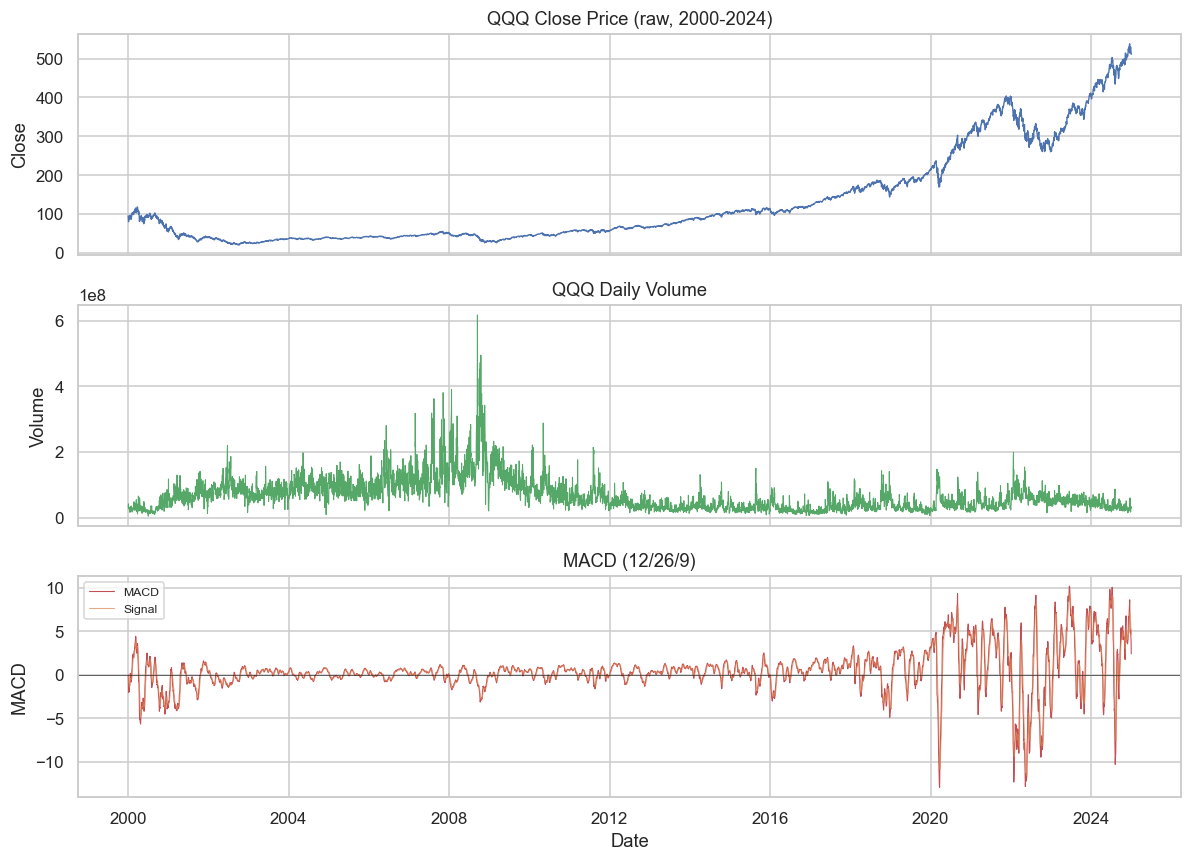

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(qqq_raw['Date'], qqq_raw['Close'], color='C0', lw=0.9)
axes[0].set_title('QQQ Close Price (raw, 2000-2024)')
axes[0].set_ylabel('Close')
axes[1].plot(qqq_raw['Date'], qqq_raw['Volume'], color='C2', lw=0.7)
axes[1].set_title('QQQ Daily Volume')
axes[1].set_ylabel('Volume')
axes[2].plot(qqq_raw['Date'], qqq_raw['MACD'], color='C3', lw=0.7, label='MACD')
axes[2].plot(qqq_raw['Date'], qqq_raw['MACD_Signal'], color='C1', lw=0.7, alpha=0.7, label='Signal')
axes[2].axhline(0, color='k', lw=0.4)
axes[2].set_title('MACD (12/26/9)')
axes[2].set_ylabel('MACD'); axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_qqq_price_volume_macd.png', dpi=150)
plt.show()


### MACD warmup zoom

The first ~30 rows of MACD are dominated by EMA initialization noise.
We drop them so the model never trains on warmup-phase MACD.


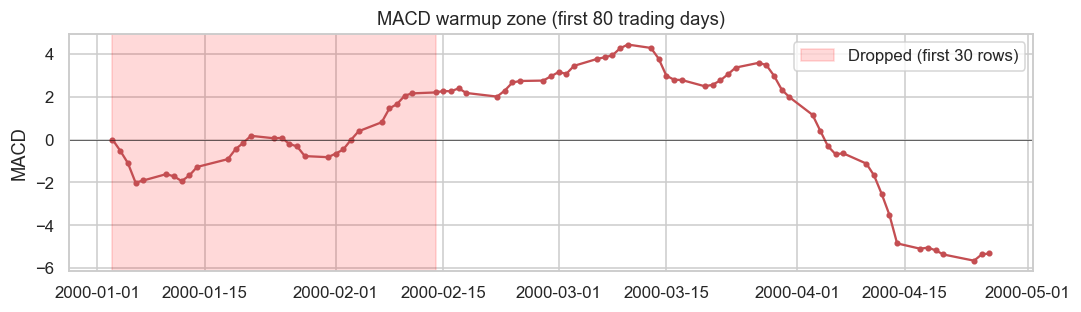

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(qqq_raw['Date'].iloc[:80], qqq_raw['MACD'].iloc[:80], marker='o', ms=3, color='C3')
ax.axvspan(qqq_raw['Date'].iloc[0], qqq_raw['Date'].iloc[WARMUP_DROP_ROWS-1],
           color='red', alpha=0.15, label=f'Dropped (first {WARMUP_DROP_ROWS} rows)')
ax.axhline(0, color='k', lw=0.4)
ax.set_title('MACD warmup zone (first 80 trading days)')
ax.set_ylabel('MACD'); ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_macd_warmup.png', dpi=150)
plt.show()


## 2. Apply MACD warmup drop and confirm split sizes

In [5]:
qqq = dl.load_qqq(drop_warmup=True)
print(f'Rows after dropping {WARMUP_DROP_ROWS} warmup rows: {len(qqq)}')
print('New effective start date:', qqq['Date'].iloc[0].date())
print('End date                :', qqq['Date'].iloc[-1].date())

split = dl.chronological_split(qqq['Date'])
print()
print(f'Train: n={len(split.train):>5}  '
      f'{split.train_dates[0].date()} -> {split.train_dates[1].date()}')
print(f'Val  : n={len(split.val):>5}  '
      f'{split.val_dates[0].date()} -> {split.val_dates[1].date()}')
print(f'Test : n={len(split.test):>5}  '
      f'{split.test_dates[0].date()} -> {split.test_dates[1].date()}')
print()
print('Sanity: train+val+test =', len(split.train)+len(split.val)+len(split.test),
      'vs total', len(qqq))


Rows after dropping 30 warmup rows: 6259
New effective start date: 2000-02-15
End date                : 2024-12-31

Train: n= 4372  2000-02-15 -> 2017-06-30
Val  : n=  943  2017-07-03 -> 2021-03-31
Test : n=  944  2021-04-01 -> 2024-12-31

Sanity: train+val+test = 6259 vs total 6259


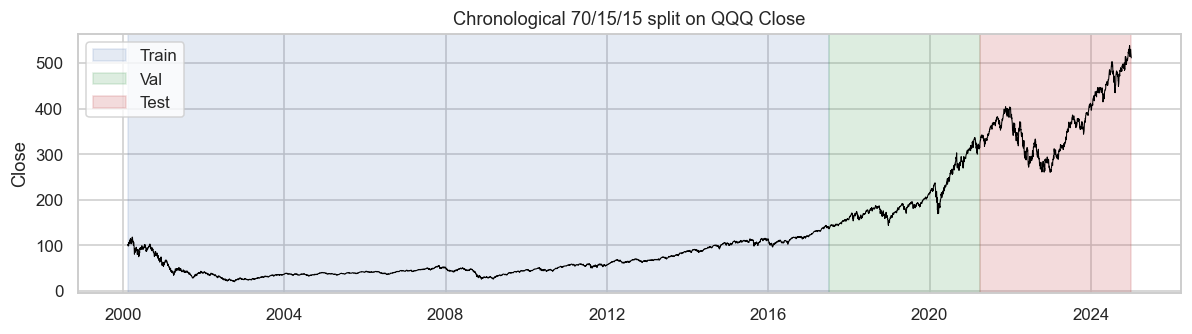

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(qqq['Date'], qqq['Close'], color='black', lw=0.7)
ax.axvspan(split.train_dates[0], split.train_dates[1], color='C0', alpha=0.15, label='Train')
ax.axvspan(split.val_dates[0],   split.val_dates[1],   color='C2', alpha=0.20, label='Val')
ax.axvspan(split.test_dates[0],  split.test_dates[1],  color='C3', alpha=0.20, label='Test')
ax.set_title('Chronological 70/15/15 split on QQQ Close')
ax.set_ylabel('Close'); ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_split_overlay.png', dpi=150)
plt.show()


## 3. Headlines corpus

In [7]:
hl = dl.load_headlines()
print('shape:', hl.shape)
print('range:', hl['date'].min().date(), '->', hl['date'].max().date())
print('null counts:'); print(hl.isnull().sum().to_string())
print('Top sources:'); print(hl['source'].value_counts().head(8).to_string())
print('Datasets   :'); print(hl['dataset'].value_counts().to_string())
hl.head()


shape: (45561, 5)
range: 2000-01-03 -> 2024-12-31
null counts:
date        0
headline    0
source      0
url         2
dataset     0
Top sources:
source
The New York Times    44840
unknown                 442
Charles Gross           103
Seeking Alpha            89
GuruFocus                31
Все                      19
Benzinga Newsdesk         9
TalkMarkets               5
Datasets   :
dataset
NYT_Archive               44840
FNSPID                      719
Kaggle_SP500_2008_2024        2


,date,headline,source,url,dataset
0,2000-01-03,Digital Commerce; An unregulated Internet may ...,The New York Times,https://www.nytimes.com/2000/01/03/business/di...,NYT_Archive
1,2000-01-03,E-Commerce Report; Traditional manufacturers a...,The New York Times,https://www.nytimes.com/2000/01/03/business/e-...,NYT_Archive
2,2000-01-03,TECHNOLOGY: Out on a Limb as Technologies Conv...,The New York Times,https://www.nytimes.com/2000/01/03/business/te...,NYT_Archive
3,2000-01-03,MEDIA: Gambling Heavily on the Tried and the T...,The New York Times,https://www.nytimes.com/2000/01/03/business/me...,NYT_Archive
4,2000-01-03,TECHNOLOGY: Out on a Limb as Technologies Conv...,The New York Times,https://www.nytimes.com/2000/01/03/business/te...,NYT_Archive


Days with at least one headline: 9130
Headline length describe:
count    45561.0
mean        68.8
std         15.5
min         10.0
25%         61.0
50%         67.0
75%         74.0
max        303.0


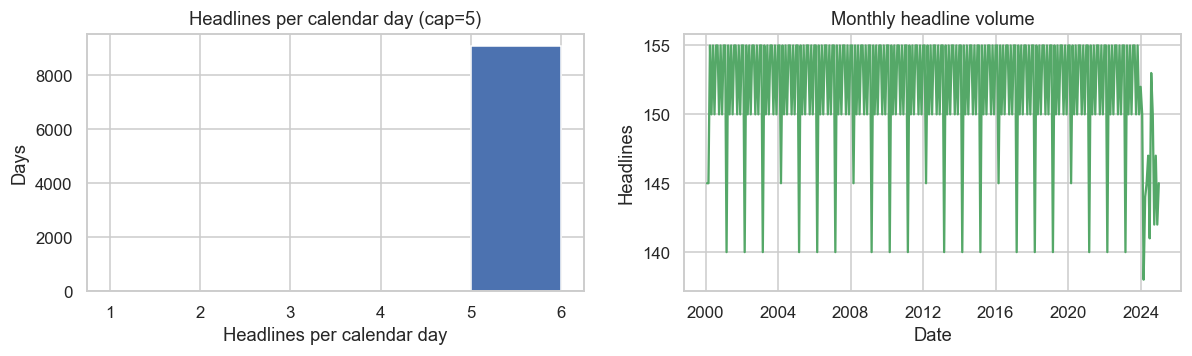

In [8]:
per_day = hl.groupby(hl['date'].dt.normalize()).size().rename('headline_count').reset_index()
per_day.columns = ['date', 'headline_count']
print('Days with at least one headline:', len(per_day))
print('Headline length describe:'); print(hl['headline'].str.len().describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(per_day['headline_count'], bins=range(1, per_day['headline_count'].max()+2),
             color='C0', edgecolor='white')
axes[0].set_xlabel('Headlines per calendar day'); axes[0].set_ylabel('Days')
axes[0].set_title('Headlines per calendar day (cap=5)')

monthly = per_day.set_index('date').resample('ME').sum()
axes[1].plot(monthly.index, monthly['headline_count'], color='C2')
axes[1].set_title('Monthly headline volume'); axes[1].set_xlabel('Date'); axes[1].set_ylabel('Headlines')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_headlines_distribution.png', dpi=150)
plt.show()


## 4. Trading days with at least one headline

In [9]:
trading_days = pd.to_datetime(qqq['Date']).dt.normalize()
trading_set = set(trading_days.tolist())
hl_dates = set(per_day['date'].tolist())

# How many headlines fall on weekends/holidays (will roll forward)?
non_trading_hl = sum(1 for d in hl['date'].dt.normalize() if d not in trading_set)
print(f'Headlines on non-trading days (will roll forward): {non_trading_hl} / {len(hl)}'
      f' ({non_trading_hl/len(hl)*100:.1f}%)')

# After roll-forward (next trading day), how many trading days end up with >=1 headline?
sorted_td = pd.Series(sorted(trading_set))
hl_norm = hl['date'].dt.normalize().values
positions = sorted_td.searchsorted(hl_norm, side='left')
in_range = positions < len(sorted_td)
assigned = sorted_td.iloc[positions[in_range]].values
covered_days = pd.Series(assigned).nunique()
print(f'Trading days covered after roll-forward: {covered_days} / {len(sorted_td)}'
      f' ({covered_days/len(sorted_td)*100:.1f}%)')


Headlines on non-trading days (will roll forward): 14266 / 45561 (31.3%)
Trading days covered after roll-forward: 6259 / 6259 (100.0%)


## 5. Summary

- **QQQ rows after warmup drop:** see printout above; effective start date logged.
- **Splits** confirmed against the brief's targets (~4,350 / ~945 / ~945) and printed
  with exact start/end dates.
- **Headline volume** is dominated by NYT_Archive - capped at 5 headlines/day for
  ~99% of covered days.
- **Coverage:** the share of trading days with at least one headline (after roll-forward)
  is printed above and motivates the `no_news_flag` feature in Mohamed's model.

Plots saved to `results/plots/01_*.png`.
